# Experiment No. 4 - Edge Detection

**Subject:** IPPR (ECE3022B) | **Program:** T.Y. B.Tech ECE AI-ML Sem-6

**AIM:** To perform edge detection using various masks in the spatial domain and to study edge linking, boundary representation.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2, os

## Generate Synthetic Test Images
Each image is designed to highlight a specific operator's strengths.

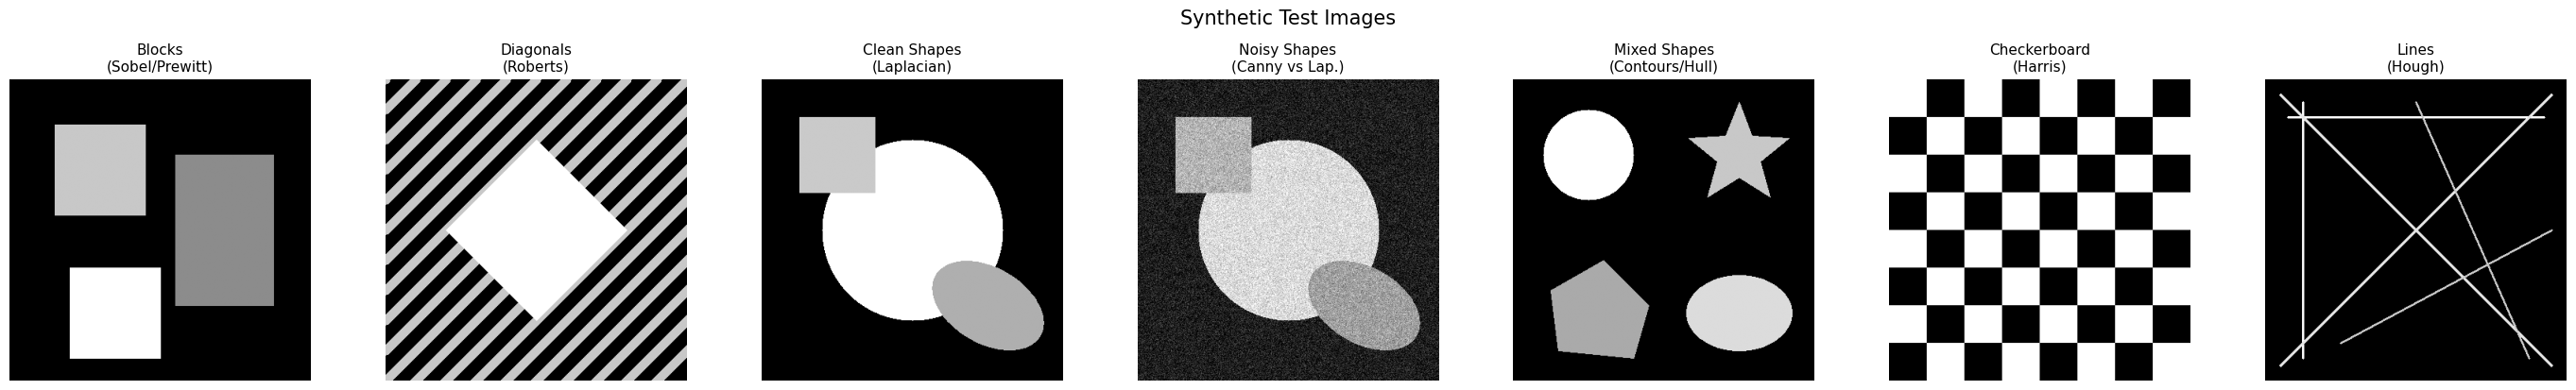

In [4]:
H, W = 400, 400

# 1. RECTANGLES / BLOCKS -> Sobel & Prewitt (clear H & V edges)
img_blocks = np.zeros((H, W), dtype=np.uint8)
cv2.rectangle(img_blocks, (60, 60), (180, 180), 200, -1)
cv2.rectangle(img_blocks, (220, 100), (350, 300), 140, -1)
cv2.rectangle(img_blocks, (80, 250), (200, 370), 255, -1)

# 2. DIAGONAL STRIPES + ROTATED SQUARE -> Roberts (diagonal edges)
img_diag = np.zeros((H, W), dtype=np.uint8)
for i in range(0, H + W, 40):
    cv2.line(img_diag, (i, 0), (0, i), 200, 12)
pts = np.array([[200, 80], [320, 200], [200, 320], [80, 200]], dtype=np.int32)
cv2.fillPoly(img_diag, [pts], 255)

# 3a. CLEAN geometric scene -> Laplacian (sharp transitions, all directions)
img_clean = np.zeros((H, W), dtype=np.uint8) + 30
cv2.circle(img_clean, (200, 200), 120, 220, -1)
cv2.rectangle(img_clean, (50, 50), (150, 150), 180, -1)
cv2.ellipse(img_clean, (300, 300), (80, 50), 30, 0, 360, 160, -1)

# 3b. NOISY version -> Canny vs Laplacian comparison
rng = np.random.default_rng(42)
noise = rng.normal(0, 25, img_clean.shape)
img_noisy = np.clip(img_clean.astype(np.float64) + noise, 0, 255).astype(np.uint8)

# 4. SHAPES: circle, star, irregular polygon -> Contours & Convex Hull
img_shapes = np.zeros((H, W), dtype=np.uint8)
cv2.circle(img_shapes, (100, 100), 60, 255, -1)
def star(cx, cy, r_out, r_in, n=5):
    pts = []
    for i in range(2 * n):
        r = r_out if i % 2 == 0 else r_in
        a = np.pi / 2 + i * np.pi / n
        pts.append([int(cx + r * np.cos(a)), int(cy - r * np.sin(a))])
    return np.array(pts, dtype=np.int32)
cv2.fillPoly(img_shapes, [star(300, 100, 70, 30)], 200)
poly = np.array([[50, 280], [120, 240], [180, 300], [160, 370], [60, 360]], dtype=np.int32)
cv2.fillPoly(img_shapes, [poly], 170)
cv2.ellipse(img_shapes, (300, 310), (70, 50), 0, 0, 360, 220, -1)

# 5. CHECKERBOARD -> Harris Corners
sq = 50
img_checker = np.zeros((H, W), dtype=np.uint8)
for r in range(H // sq):
    for c in range(W // sq):
        if (r + c) % 2 == 0:
            img_checker[r*sq:(r+1)*sq, c*sq:(c+1)*sq] = 255

# 6. LINES AT VARIOUS ANGLES -> Hough Transform
img_lines = np.zeros((H, W), dtype=np.uint8)
cv2.line(img_lines, (30, 50), (370, 50), 200, 2)
cv2.line(img_lines, (50, 30), (50, 370), 200, 2)
cv2.line(img_lines, (20, 380), (380, 20), 180, 2)
cv2.line(img_lines, (20, 20), (380, 380), 180, 2)
cv2.line(img_lines, (200, 30), (350, 370), 160, 2)
cv2.line(img_lines, (100, 350), (380, 200), 160, 2)

# --- Display all synthetic images ---
synth = [
    (img_blocks, "Blocks\n(Sobel/Prewitt)"),
    (img_diag,   "Diagonals\n(Roberts)"),
    (img_clean,  "Clean Shapes\n(Laplacian)"),
    (img_noisy,  "Noisy Shapes\n(Canny vs Lap.)"),
    (img_shapes, "Mixed Shapes\n(Contours/Hull)"),
    (img_checker,"Checkerboard\n(Harris)"),
    (img_lines,  "Lines\n(Hough)")
]

fig, axes = plt.subplots(1, 7, figsize=(28, 4))
for ax, (im, t) in zip(axes, synth):
    ax.imshow(im, cmap='gray'); ax.set_title(t, fontsize=11); ax.axis('off')
fig.suptitle("Synthetic Test Images", fontsize=15, y=1.02)
plt.tight_layout(); plt.show()

## Part A: Gradient and Laplacian Edge Detection
### A1. Sobel

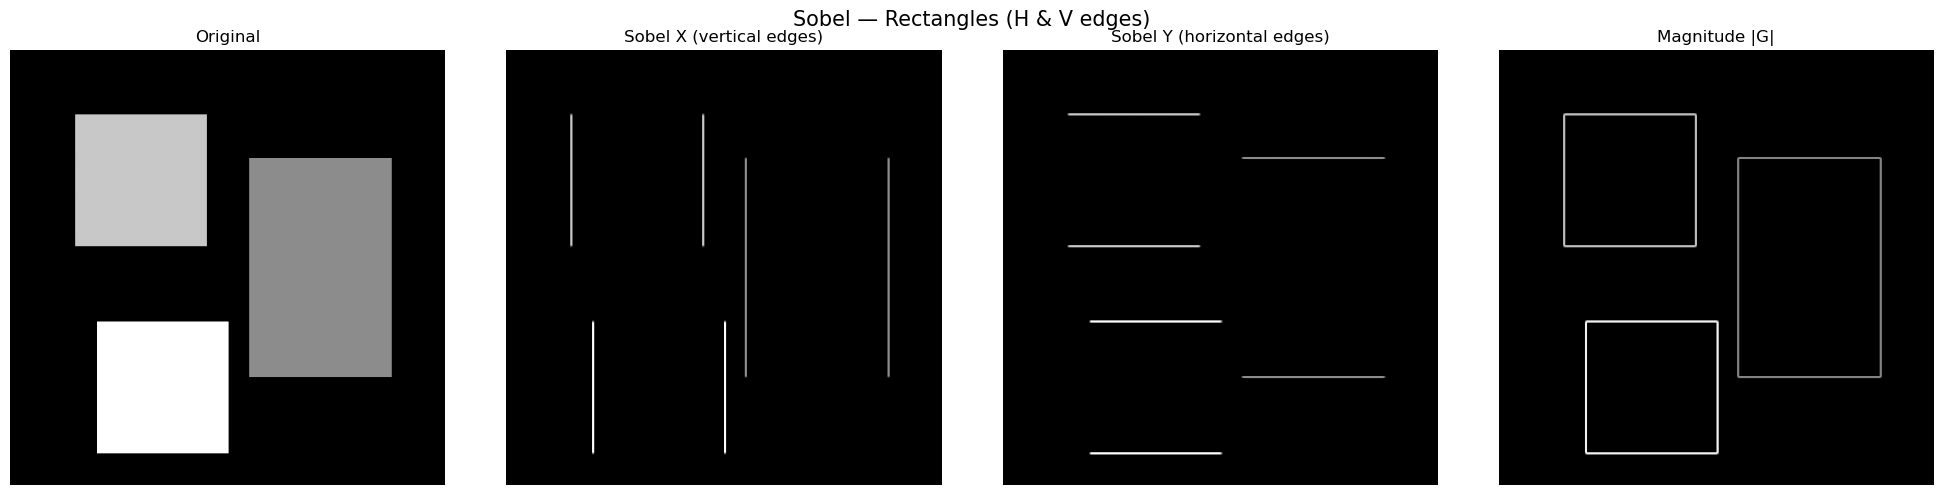

In [5]:
# Sobel on BLOCKS image — clear horizontal & vertical edges
g = img_blocks
sx = cv2.Sobel(g, cv2.CV_64F, 1, 0, ksize=3)
sy = cv2.Sobel(g, cv2.CV_64F, 0, 1, ksize=3)
mag = np.sqrt(sx**2 + sy**2)

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Sobel — Rectangles (H & V edges)", fontsize=15)
ax[0].imshow(g, cmap='gray');  ax[0].set_title("Original");  ax[0].axis('off')
ax[1].imshow(np.abs(sx), cmap='gray'); ax[1].set_title("Sobel X (vertical edges)");   ax[1].axis('off')
ax[2].imshow(np.abs(sy), cmap='gray'); ax[2].set_title("Sobel Y (horizontal edges)"); ax[2].axis('off')
ax[3].imshow(mag, cmap='gray');         ax[3].set_title("Magnitude |G|");              ax[3].axis('off')
plt.tight_layout(); plt.show()

### A2. Prewitt

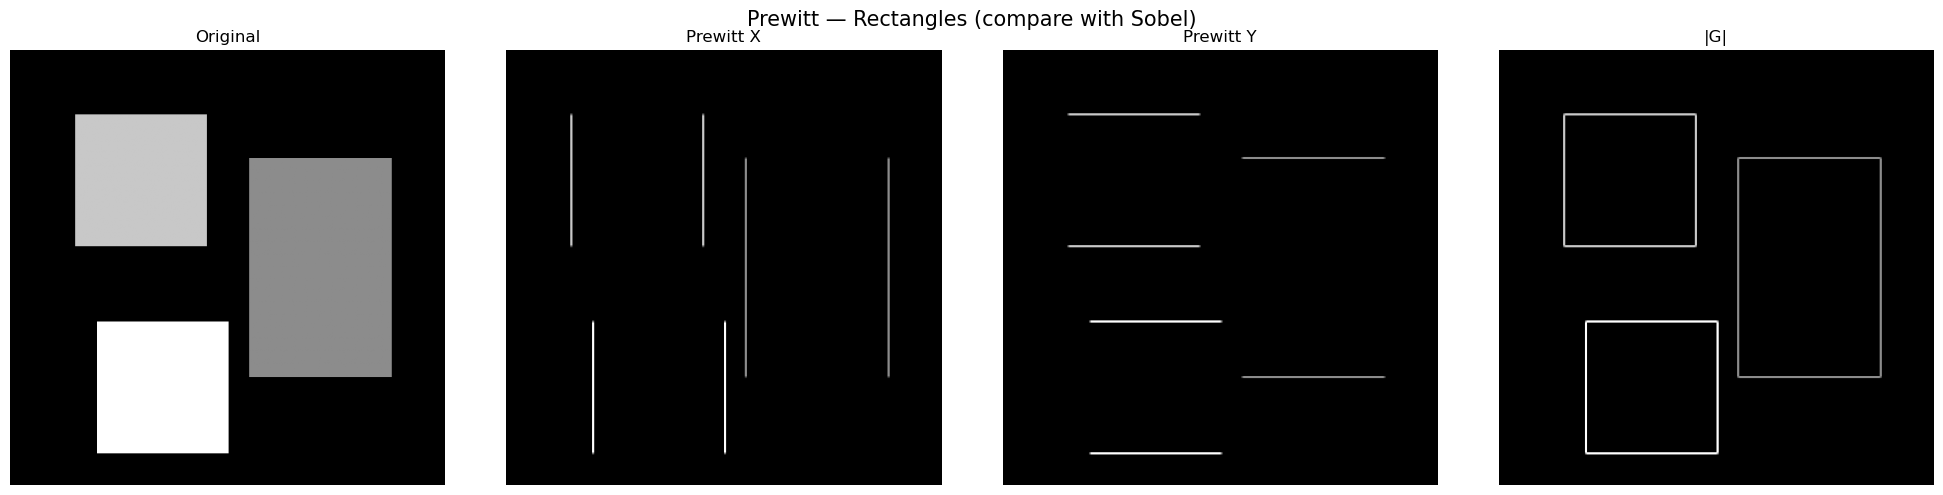

In [6]:
# Prewitt on BLOCKS — compare directly with Sobel
Px = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float64)
Py = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float64)
g = img_blocks
px = cv2.filter2D(g, cv2.CV_64F, Px)
py = cv2.filter2D(g, cv2.CV_64F, Py)
pmag = np.sqrt(px**2 + py**2)

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Prewitt — Rectangles (compare with Sobel)", fontsize=15)
ax[0].imshow(g, cmap='gray');   ax[0].set_title("Original");   ax[0].axis('off')
ax[1].imshow(np.abs(px), cmap='gray'); ax[1].set_title("Prewitt X"); ax[1].axis('off')
ax[2].imshow(np.abs(py), cmap='gray'); ax[2].set_title("Prewitt Y"); ax[2].axis('off')
ax[3].imshow(pmag, cmap='gray');        ax[3].set_title("|G|");       ax[3].axis('off')
plt.tight_layout(); plt.show()

### A3. Roberts

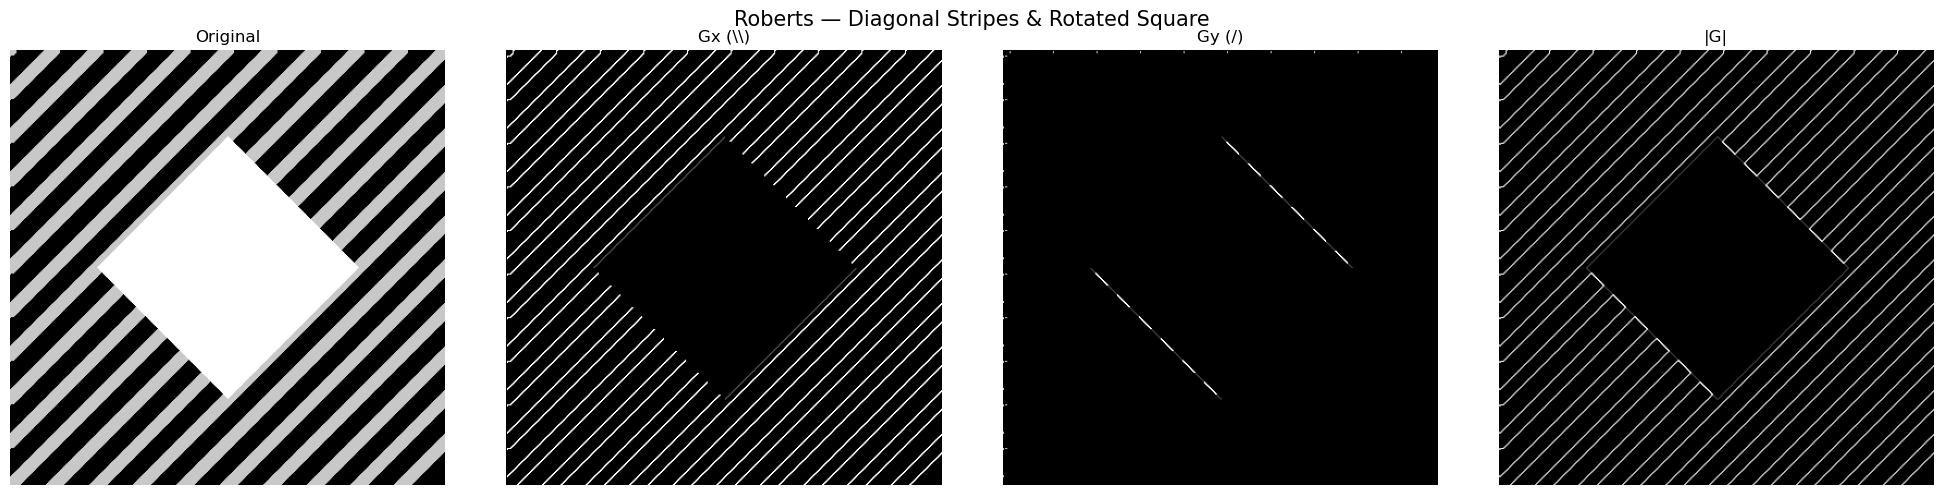

In [7]:
# Roberts on DIAGONAL image — diagonal edges preserved
Rx = np.array([[1, 0], [0, -1]], dtype=np.float64)
Ry = np.array([[0, 1], [-1, 0]], dtype=np.float64)
g = img_diag
rx = cv2.filter2D(g, cv2.CV_64F, Rx)
ry = cv2.filter2D(g, cv2.CV_64F, Ry)
rmag = np.sqrt(rx**2 + ry**2)

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Roberts — Diagonal Stripes & Rotated Square", fontsize=15)
ax[0].imshow(g, cmap='gray');   ax[0].set_title("Original");       ax[0].axis('off')
ax[1].imshow(np.abs(rx), cmap='gray'); ax[1].set_title("Gx (\\\\)"); ax[1].axis('off')
ax[2].imshow(np.abs(ry), cmap='gray'); ax[2].set_title("Gy (/)");     ax[2].axis('off')
ax[3].imshow(rmag, cmap='gray');        ax[3].set_title("|G|");         ax[3].axis('off')
plt.tight_layout(); plt.show()

### A4. Laplacian

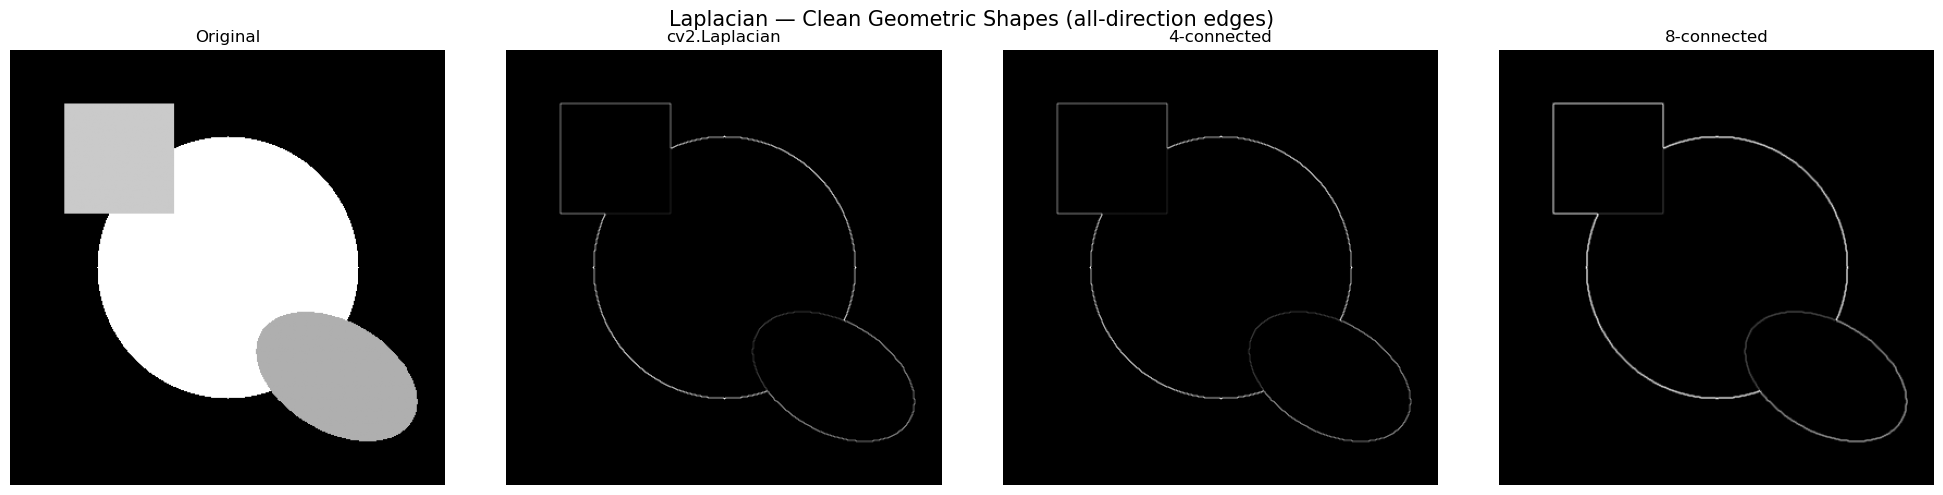

In [8]:
# Laplacian on CLEAN shapes — sharp transitions, all directions
g = img_clean
L4 = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float64)
L8 = np.array([[1, 1, 1], [1, -8, 1], [1, 1, 1]], dtype=np.float64)
lap = cv2.Laplacian(g, cv2.CV_64F)
l4 = cv2.filter2D(g, cv2.CV_64F, L4)
l8 = cv2.filter2D(g, cv2.CV_64F, L8)

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Laplacian — Clean Geometric Shapes (all-direction edges)", fontsize=15)
ax[0].imshow(g, cmap='gray');          ax[0].set_title("Original");       ax[0].axis('off')
ax[1].imshow(np.abs(lap), cmap='gray'); ax[1].set_title("cv2.Laplacian"); ax[1].axis('off')
ax[2].imshow(np.abs(l4), cmap='gray');  ax[2].set_title("4-connected");   ax[2].axis('off')
ax[3].imshow(np.abs(l8), cmap='gray');  ax[3].set_title("8-connected");   ax[3].axis('off')
plt.tight_layout(); plt.show()

### A5. Comparison

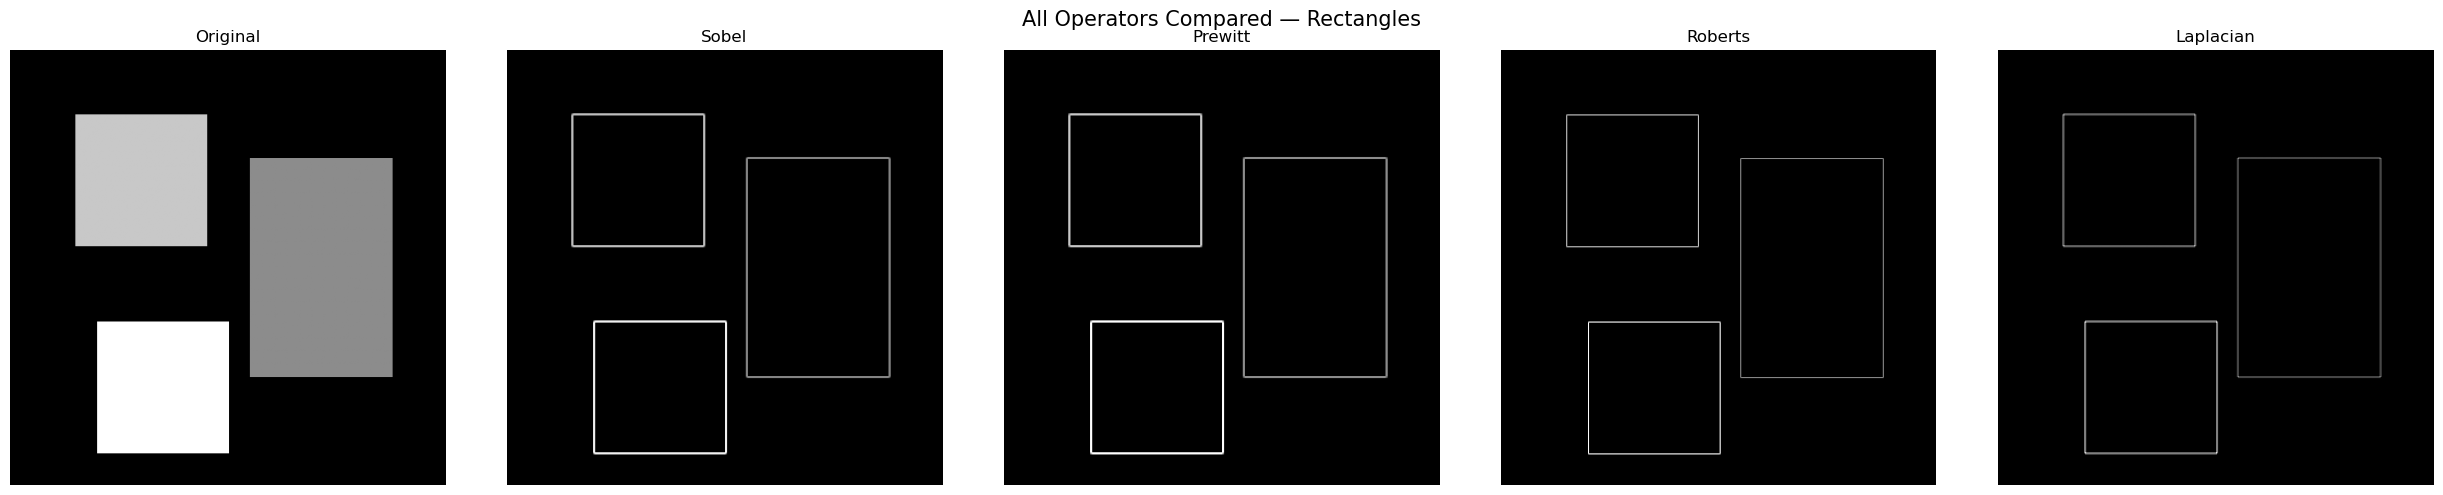

In [9]:
# Side-by-side comparison of ALL gradient operators on blocks image
g = img_blocks
sx = cv2.Sobel(g, cv2.CV_64F, 1, 0, ksize=3); sy = cv2.Sobel(g, cv2.CV_64F, 0, 1, ksize=3)
s = np.sqrt(sx**2 + sy**2)
px = cv2.filter2D(g, cv2.CV_64F, Px); py = cv2.filter2D(g, cv2.CV_64F, Py)
p = np.sqrt(px**2 + py**2)
rx = cv2.filter2D(g, cv2.CV_64F, Rx); ry = cv2.filter2D(g, cv2.CV_64F, Ry)
r = np.sqrt(rx**2 + ry**2)
l = np.abs(cv2.Laplacian(g, cv2.CV_64F))

fig, ax = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle("All Operators Compared — Rectangles", fontsize=15)
for a, im, t in zip(ax, [g, s, p, r, l], ["Original", "Sobel", "Prewitt", "Roberts", "Laplacian"]):
    a.imshow(im, cmap='gray'); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()

## Part B: Edge Linking & Boundary Representation
### B1. Canny vs Laplacian (Noise Robustness)

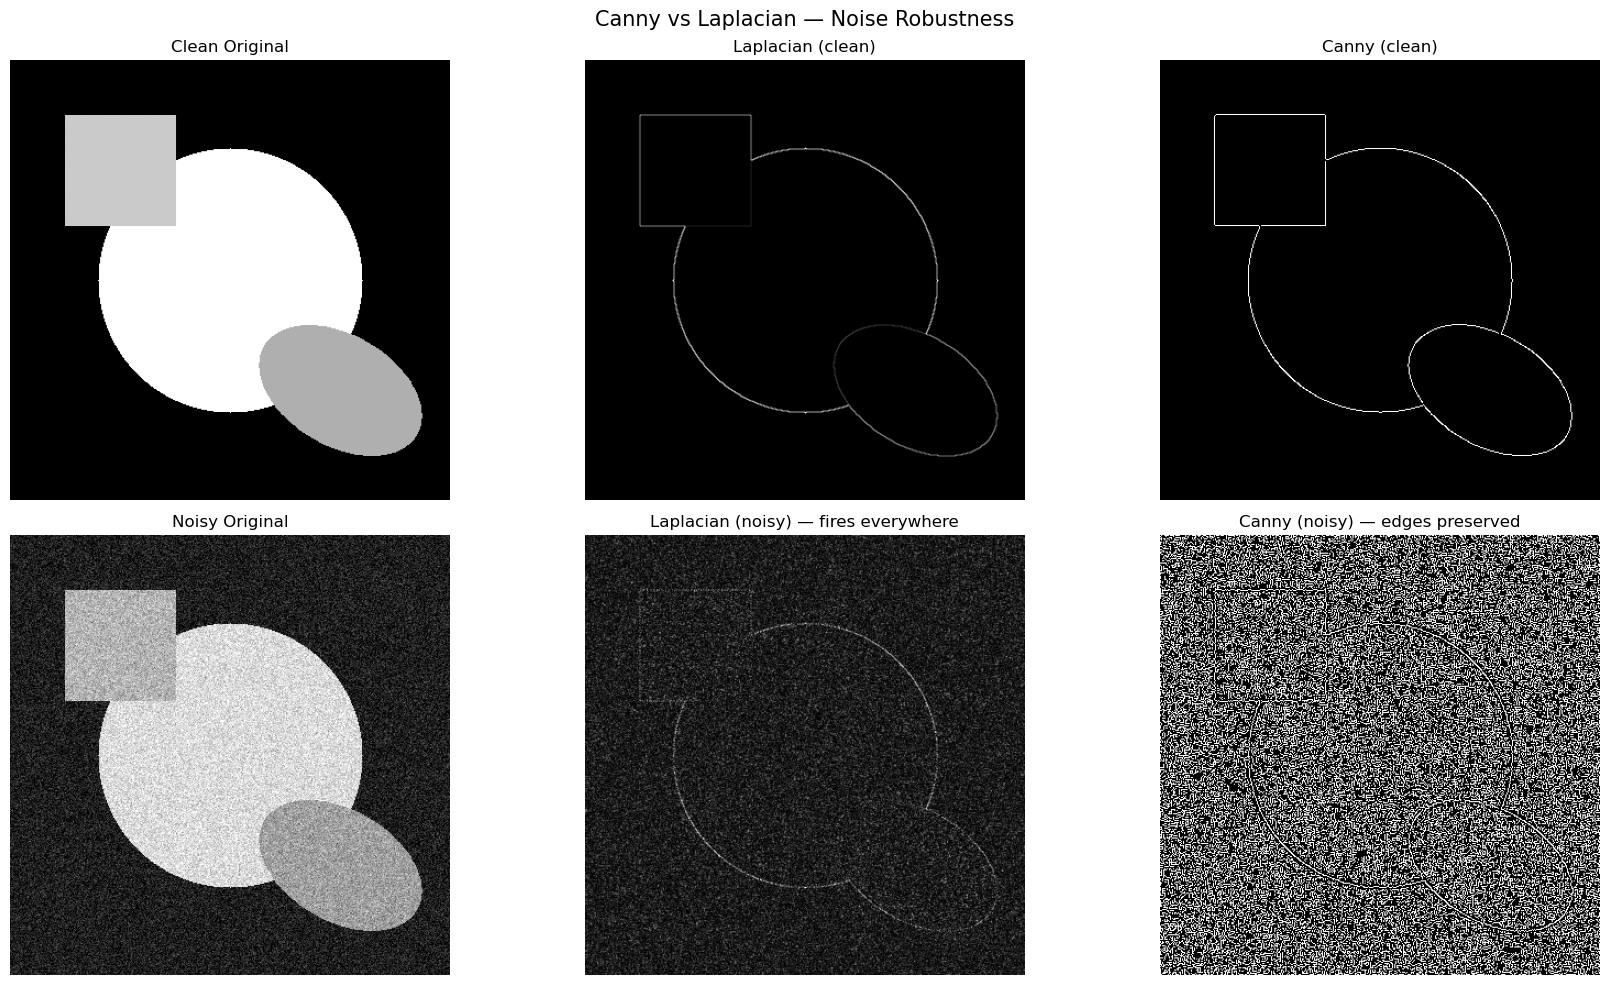

In [10]:
# Canny vs Laplacian on NOISY image — shows Canny's noise robustness
fig, ax = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Canny vs Laplacian — Noise Robustness", fontsize=15)

# Row 0: Clean image
ax[0, 0].imshow(img_clean, cmap='gray'); ax[0, 0].set_title("Clean Original"); ax[0, 0].axis('off')
ax[0, 1].imshow(np.abs(cv2.Laplacian(img_clean, cv2.CV_64F)), cmap='gray')
ax[0, 1].set_title("Laplacian (clean)"); ax[0, 1].axis('off')
ax[0, 2].imshow(cv2.Canny(img_clean, 50, 150), cmap='gray')
ax[0, 2].set_title("Canny (clean)"); ax[0, 2].axis('off')

# Row 1: Noisy image
ax[1, 0].imshow(img_noisy, cmap='gray'); ax[1, 0].set_title("Noisy Original"); ax[1, 0].axis('off')
ax[1, 1].imshow(np.abs(cv2.Laplacian(img_noisy, cv2.CV_64F)), cmap='gray')
ax[1, 1].set_title("Laplacian (noisy) — fires everywhere"); ax[1, 1].axis('off')
ax[1, 2].imshow(cv2.Canny(img_noisy, 50, 150), cmap='gray')
ax[1, 2].set_title("Canny (noisy) — edges preserved"); ax[1, 2].axis('off')

plt.tight_layout(); plt.show()

### B2. LoG (Marr-Hildreth)

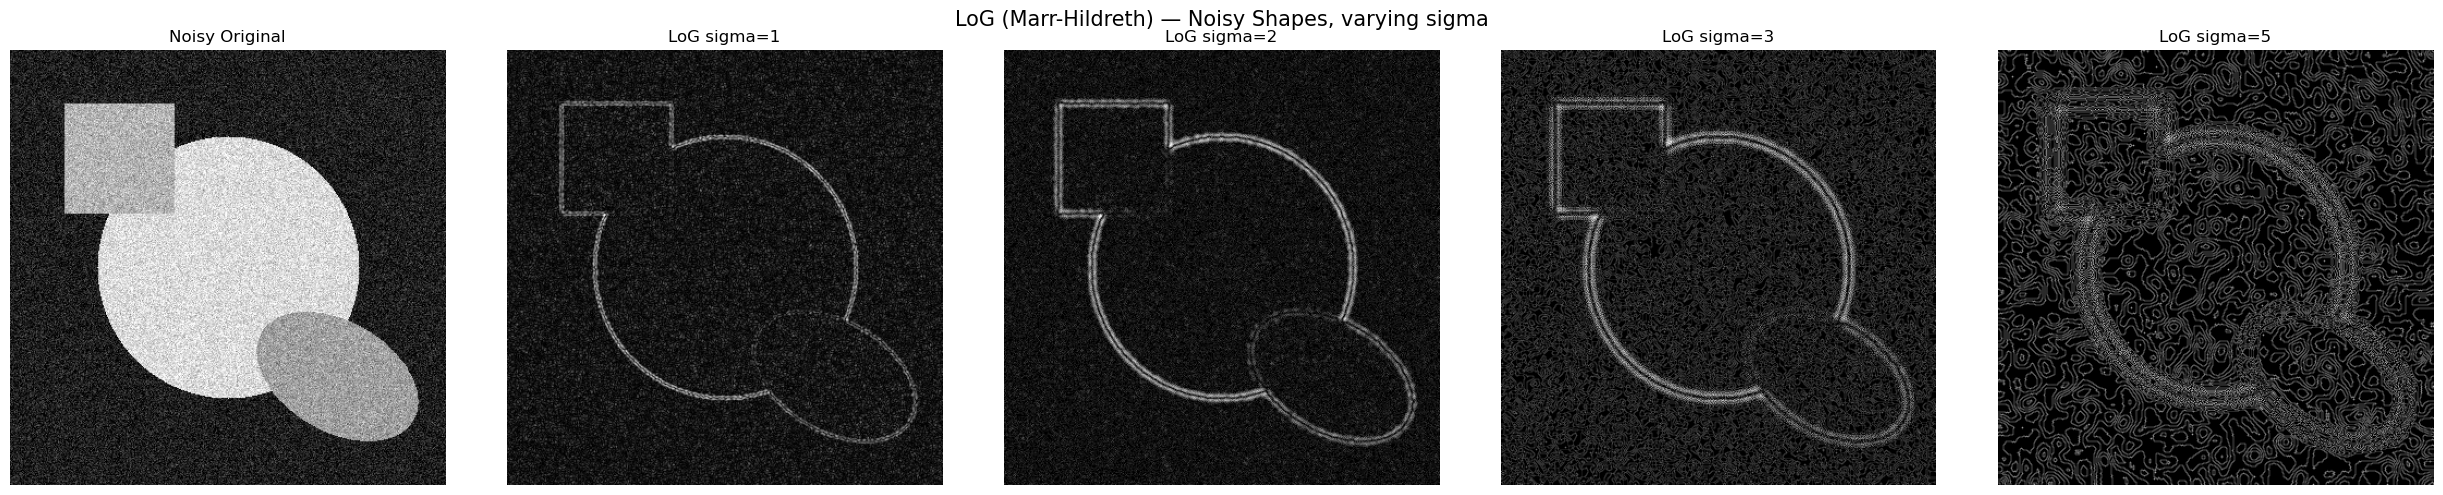

In [11]:
# LoG on NOISY image — Gaussian smoothing tames noise before Laplacian
g = img_noisy
fig, ax = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle("LoG (Marr-Hildreth) — Noisy Shapes, varying sigma", fontsize=15)
ax[0].imshow(g, cmap='gray'); ax[0].set_title("Noisy Original"); ax[0].axis('off')
for i, sig in enumerate([1, 2, 3, 5]):
    k = int(6 * sig + 1) | 1
    blurred = cv2.GaussianBlur(g, (k, k), sig)
    lo = cv2.Laplacian(blurred, cv2.CV_64F)
    ax[i + 1].imshow(np.abs(lo), cmap='gray')
    ax[i + 1].set_title(f"LoG sigma={sig}"); ax[i + 1].axis('off')
plt.tight_layout(); plt.show()

### B3. Contours

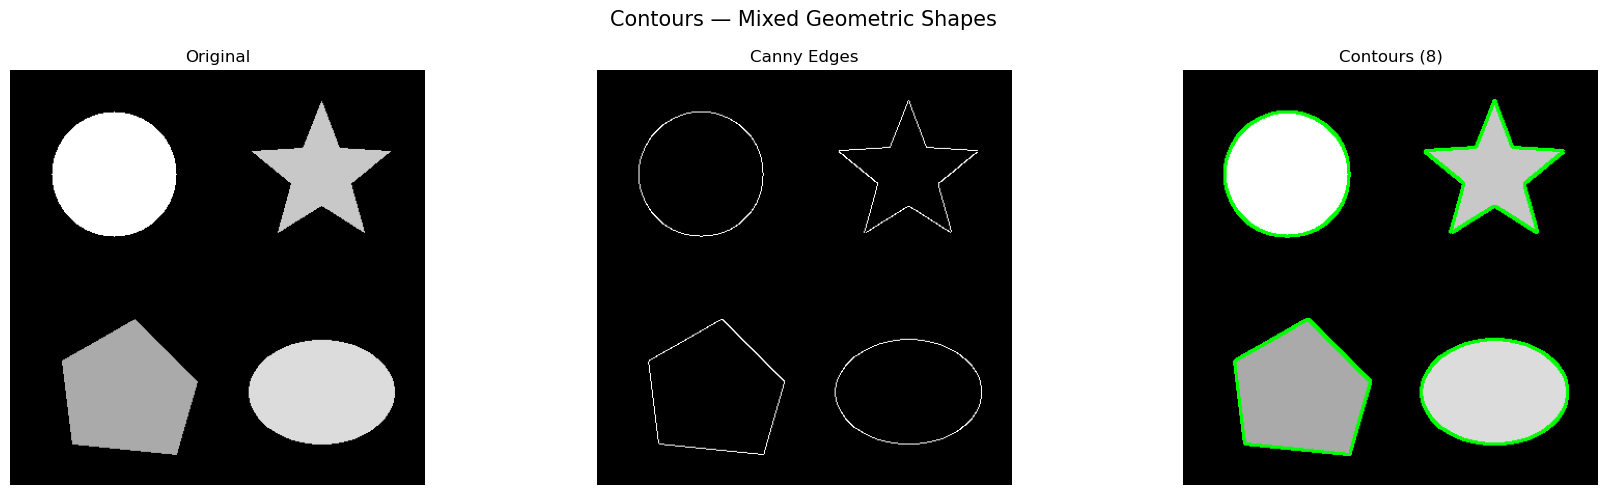

In [12]:
# Contours on SHAPES image — circle, star, polygon, ellipse
g = img_shapes
rgb = cv2.cvtColor(cv2.merge([g, g, g]), cv2.COLOR_BGR2RGB)
edges = cv2.Canny(g, 50, 150)
contours, _ = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
img_cnt = rgb.copy()
cv2.drawContours(img_cnt, contours, -1, (0, 255, 0), 2)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Contours — Mixed Geometric Shapes", fontsize=15)
ax[0].imshow(g, cmap='gray');    ax[0].set_title("Original");         ax[0].axis('off')
ax[1].imshow(edges, cmap='gray'); ax[1].set_title("Canny Edges");     ax[1].axis('off')
ax[2].imshow(img_cnt);            ax[2].set_title(f"Contours ({len(contours)})"); ax[2].axis('off')
plt.tight_layout(); plt.show()

### B4. Convex Hull

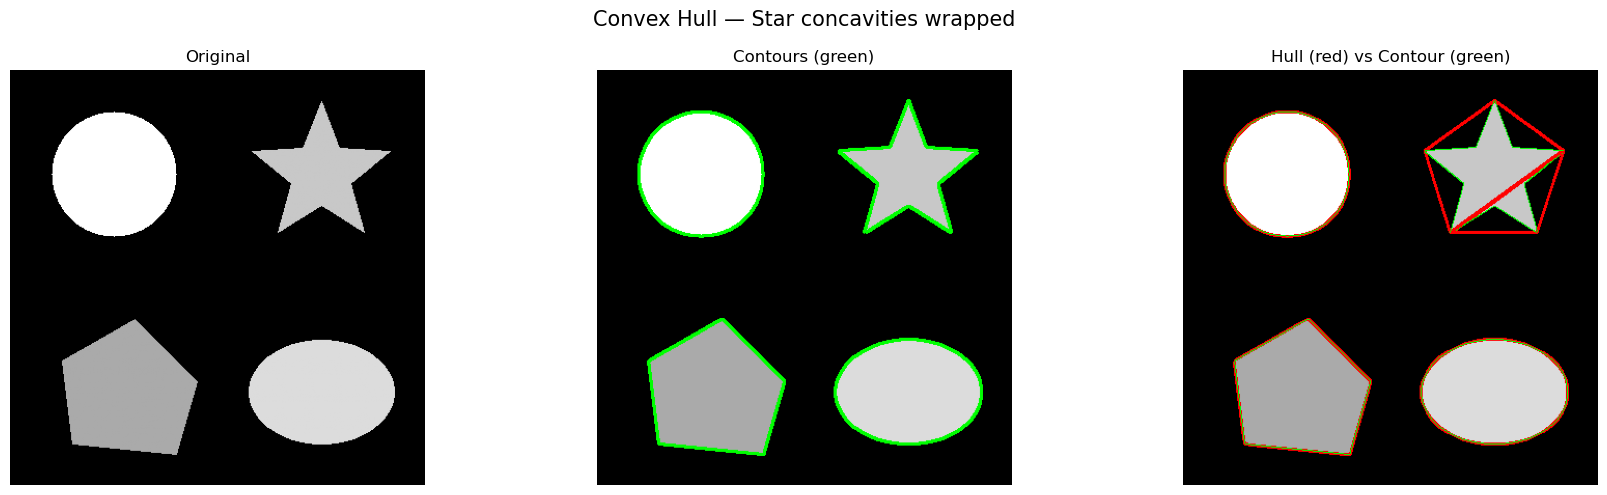

In [13]:
# Convex Hull on SHAPES — star's concavities get wrapped
g = img_shapes
rgb = cv2.cvtColor(cv2.merge([g, g, g]), cv2.COLOR_BGR2RGB)
edges = cv2.Canny(g, 50, 150)
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_cnt = rgb.copy()
cv2.drawContours(img_cnt, contours, -1, (0, 255, 0), 2)

img_hull = rgb.copy()
for c in contours:
    hull = cv2.convexHull(c)
    cv2.drawContours(img_hull, [hull], 0, (255, 0, 0), 2)
    cv2.drawContours(img_hull, [c], 0, (0, 255, 0), 1)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Convex Hull — Star concavities wrapped", fontsize=15)
ax[0].imshow(g, cmap='gray');  ax[0].set_title("Original");  ax[0].axis('off')
ax[1].imshow(img_cnt);         ax[1].set_title("Contours (green)"); ax[1].axis('off')
ax[2].imshow(img_hull);        ax[2].set_title("Hull (red) vs Contour (green)"); ax[2].axis('off')
plt.tight_layout(); plt.show()

### B5. Hough Line Transform

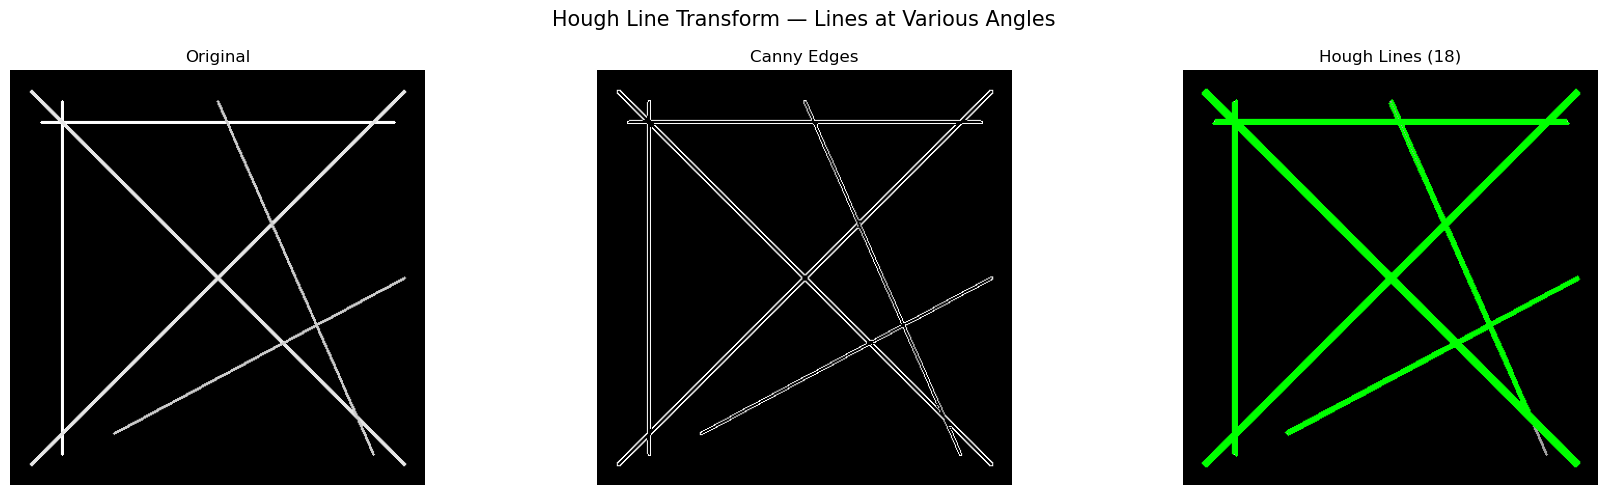

In [14]:
# Hough Line Transform on LINES image — lines at various angles
g = img_lines
edges = cv2.Canny(g, 50, 150)
lines_detected = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=30,
                                  minLineLength=20, maxLineGap=10)
rgb = cv2.cvtColor(cv2.merge([g, g, g]), cv2.COLOR_BGR2RGB)
img_hough = rgb.copy()
if lines_detected is not None:
    for l in lines_detected:
        cv2.line(img_hough, tuple(l[0][:2]), tuple(l[0][2:]), (0, 255, 0), 2)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Hough Line Transform — Lines at Various Angles", fontsize=15)
ax[0].imshow(g, cmap='gray');     ax[0].set_title("Original");    ax[0].axis('off')
ax[1].imshow(edges, cmap='gray'); ax[1].set_title("Canny Edges"); ax[1].axis('off')
nl = len(lines_detected) if lines_detected is not None else 0
ax[2].imshow(img_hough);          ax[2].set_title(f"Hough Lines ({nl})"); ax[2].axis('off')
plt.tight_layout(); plt.show()

### B6. Harris Corner Detection

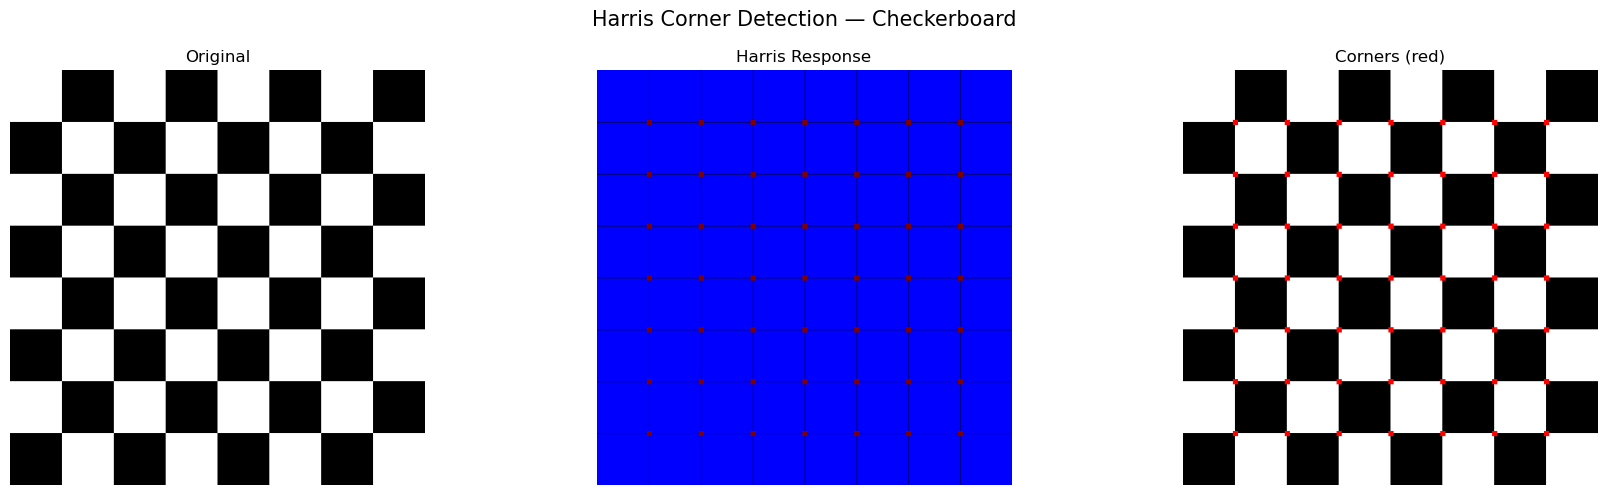

In [15]:
# Harris Corners on CHECKERBOARD — clean corner response
g = img_checker
harris = cv2.cornerHarris(np.float32(g), blockSize=2, ksize=3, k=0.04)
harris = cv2.dilate(harris, None)

rgb = cv2.cvtColor(cv2.merge([g, g, g]), cv2.COLOR_BGR2RGB)
img_harris = rgb.copy()
img_harris[harris > 0.01 * harris.max()] = [255, 0, 0]

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Harris Corner Detection — Checkerboard", fontsize=15)
ax[0].imshow(g, cmap='gray');       ax[0].set_title("Original");         ax[0].axis('off')
ax[1].imshow(harris, cmap='jet');   ax[1].set_title("Harris Response");  ax[1].axis('off')
ax[2].imshow(img_harris);           ax[2].set_title("Corners (red)");    ax[2].axis('off')
plt.tight_layout(); plt.show()

---
## Result and Conclusion

**Part A:**
- **Sobel**: First-order derivative; X kernel detects vertical edges, Y kernel detects horizontal edges. Rectangles image clearly shows independent directional responses.
- **Prewitt**: Similar to Sobel but with equal weighting (no center emphasis), slightly less noise-resistant. Nearly identical output on clean synthetic blocks.
- **Roberts**: 2x2 diagonal kernels; excels on the diagonal stripes and rotated square where Sobel/Prewitt would miss 45-degree edges.
- **Laplacian**: Second-order derivative, detects edges in all directions simultaneously. Clean shapes image shows crisp boundaries for circles, rectangles, and ellipses alike.

**Part B:**
- **Canny**: Most robust edge detector (Gaussian smoothing + NMS + hysteresis). Noisy image comparison shows Canny preserving true edges while Laplacian fires on every noise pixel.
- **LoG**: Gaussian + Laplacian; increasing sigma progressively suppresses noise but also blurs fine edges.
- **Contours**: Edge linking groups Canny edge pixels into connected boundaries around each shape.
- **Convex Hull**: Wraps each contour in its smallest convex polygon. Most visible on the star where concavities are filled in.
- **Hough Transform**: Links collinear edge points into parametric lines. Recovers all 6 lines at different angles from the synthetic lines image.
- **Harris Corners**: Detects corners via eigenvalues of the structure tensor. Checkerboard produces clean, unambiguous corner responses at every grid intersection.

---
## Questions

**Q1. Apply the Sobel edge detector and Laplacian edge detector on the highlighted area and comment on the result.**

Given 5x5 matrix:
```
 12   12   12   12   12
 12   12   12   12   12
 12   12   12   12   12
201  201  201  201  201
201  201  201  201  201
```

**Sobel Y** at pixel (2,2): Gy = (-1)(12) + (-2)(12) + (-1)(12) + (1)(201) + (2)(201) + (1)(201) = -48 + 804 = **756**, Gx = 0 (no horizontal intensity change). |G| = 756 — strong horizontal edge detected.

**Laplacian (4-conn)** at (2,2): 12 + 12 + 201 + 12 - 4(12) = 237 - 48 = **+189**. At (3,2): 12 + 201 + 201 + 201 - 4(201) = 615 - 804 = **-189**. Zero-crossing between rows 2 and 3 confirms the edge location.

**Comment**: Both detectors identify the strong horizontal edge between rows 2-3 (intensity jump from 12 to 201 = 189). Sobel Y gives a large positive gradient magnitude. Laplacian shows a sign change (zero-crossing) at the edge boundary. Sobel X = 0 everywhere since there is no vertical intensity variation.